# 10 · Keep observed conductors separate from a fitted curve

Audit a public AHN4 point-cloud crop, select one observed conductor segment, fit an exploratory catenary, inspect withheld along-track blocks, and export measured points and generated geometry in distinct GeoPackage layers.

[Notebook index](README.md) · [Companion article](../docs/articles/lidar-evidence.md) · [Data sources and licences](../docs/DATA_SOURCES.md)

Run every cell from top to bottom in the locked Python 3.12 environment. The first run downloads the required public data pack and checks its SHA-256. Generated artifacts remain in the ignored `outputs/` directory.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display

from geoai_portfolio.io import ensure_data, workspace

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.figsize": (10, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
        "axes.titlesize": 11,
        "font.size": 10,
        "savefig.bbox": "tight",
    }
)
pd.set_option("display.precision", 4)

In [2]:
import geopandas as gpd
import laspy

from geoai_portfolio.lidar import coordinates, fit_catenary

data = ensure_data("ahn")
out = workspace("10-lidar")
cloud = laspy.read(data / "corridor.laz")
xyz = coordinates(cloud)
original_xyz = xyz.copy()
classes, counts = np.unique(cloud.classification, return_counts=True)
names = {1: "Unclassified", 2: "Ground", 6: "Building", 9: "Water", 14: "Wire conductor"}
display(
    pd.DataFrame(
        {
            "class": classes,
            "meaning": [names.get(int(c), f"Provider code {c}") for c in classes],
            "observations": counts,
        }
    )
)
provenance = json.loads((data / "provenance.json").read_text())
print(
    {
        "compound_crs": provenance["compound_crs"],
        "units": "metres",
        "UTC_range": provenance["gps_utc_ranges"]["corridor"],
        "CRS_assignment": provenance["crs_action"],
    }
)

,class,meaning,observations
0,1,Unclassified,155458
1,2,Ground,1382828
2,6,Building,12480
3,14,Wire conductor,1999


{'compound_crs': 'EPSG:7415', 'units': 'metres', 'UTC_range': ['2022-02-12T08:20:11.040792Z', '2022-02-12T08:20:21.795144Z'], 'CRS_assignment': 'Original LAS header lacks CRS; assigned provider-documented CRS, no transform'}


## Inspect evidence and select a bounded segment

Coordinates and classifications are retained from the source. Class 1 is unclassified,
not an automatic vegetation label. The overview thins points for display only; selection
and fitting use all relevant observations. Class 14 supplies conductor candidates.
We inspect a known straight corridor and choose northing 446100–446330 m with Z above
30.5 m NAP, then separate parallel traces by their lateral position. This is an explicit
case-specific selection, not a general network-reconstruction algorithm.

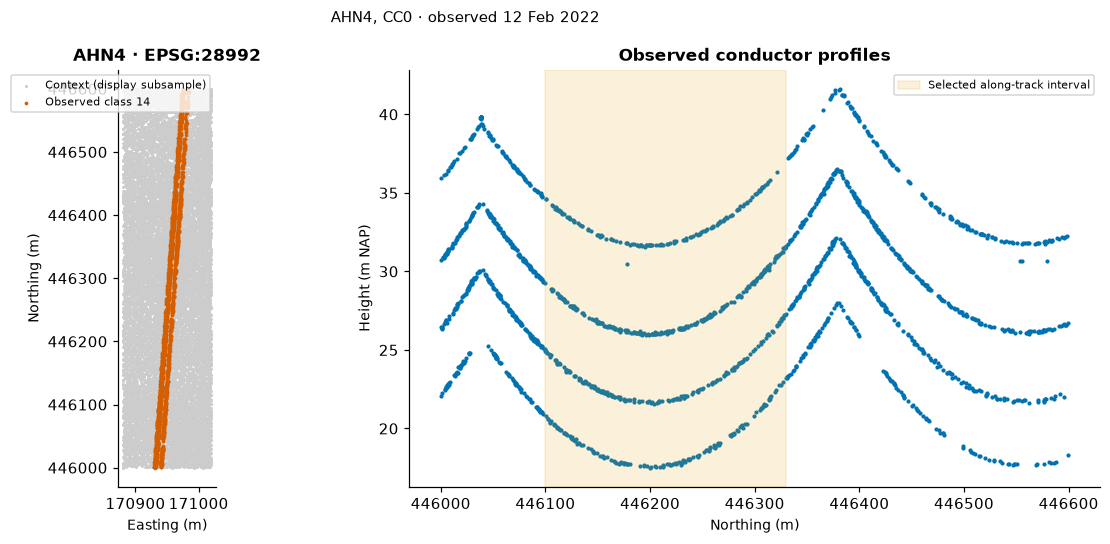

In [3]:
wire_mask = np.asarray(cloud.classification) == 14
wires = xyz[wire_mask]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
context = xyz[::100]
axes[0].scatter(context[:, 0], context[:, 1], c="#cccccc", s=1, label="Context (display subsample)")
axes[0].scatter(wires[:, 0], wires[:, 1], c="#D55E00", s=2, label="Observed class 14")
axes[0].set(title="AHN4 · EPSG:28992", xlabel="Easting (m)", ylabel="Northing (m)", aspect="equal")
axes[0].ticklabel_format(useOffset=False)
axes[0].legend(fontsize=7)
axes[1].scatter(wires[:, 1], wires[:, 2], s=3, color="#0072B2")
axes[1].axvspan(446100, 446330, color="#E69F00", alpha=0.15, label="Selected along-track interval")
axes[1].set(title="Observed conductor profiles", xlabel="Northing (m)", ylabel="Height (m NAP)")
axes[1].ticklabel_format(useOffset=False)
axes[1].legend(fontsize=7)
fig.suptitle("AHN4, CC0 · observed 12 Feb 2022", fontsize=10)
plt.tight_layout()
plt.show()

In [4]:
from sklearn.cluster import DBSCAN

candidate = wires[(wires[:, 1] > 446100) & (wires[:, 1] < 446330) & (wires[:, 2] > 30.5)]
center = candidate[:, :2].mean(0)
direction = np.linalg.svd(candidate[:, :2] - center, full_matrices=False)[2][0]
lateral = (candidate[:, :2] - center) @ np.array([-direction[1], direction[0]])
clusters = DBSCAN(eps=0.4, min_samples=5).fit_predict(lateral[:, None])
available = sorted(set(clusters) - {-1})
if not available:
    raise ValueError("No supported lateral trace")
chosen = max(available, key=lambda label: int((clusters == label).sum()))
observed = candidate[clusters == chosen].copy()
# Hold out every fifth 20-m northing block before fitting.
block = np.floor((observed[:, 1] - 446100) / 20).astype(int)
held_out = block % 5 == 2
fit = fit_catenary(observed[~held_out])
a, s0, z0 = fit["parameters"]
s_test = (observed[held_out, :2] - fit["origin"]) @ fit["axis"]
z_test = a * (np.cosh((s_test - s0) / a) - 1) + z0
test_residual = observed[held_out, 2] - z_test
display(
    pd.DataFrame(
        {
            "partition": ["fit", "withheld along-track blocks"],
            "points": [(~held_out).sum(), held_out.sum()],
            "vertical_RMSE_m": [fit["rmse_m"], np.sqrt(np.mean(test_residual**2))],
        }
    )
)
print("Fitted parameters [a, s0, z0]:", np.round(fit["parameters"], 3))

,partition,points,vertical_RMSE_m
0,fit,114,0.0377
1,withheld along-track blocks,25,0.0417


Fitted parameters [a, s0, z0]: [1636.861  -13.247   31.662]


## A small residual does not establish operational accuracy

The fitted equation is `z = a(cosh((s − s0)/a) − 1) + z0`, with a PCA horizontal axis.
Robust least squares uses a 0.25 m residual scale and bounded parameters. Withheld
along-track blocks test local interpolation on this acquisition. They do not measure
absolute survey error, generalisation to other spans, or conductor movement under
different load, wind or temperature. No independent control points or complete vertical
accuracy budget are available, so these data do not support a clearance decision.

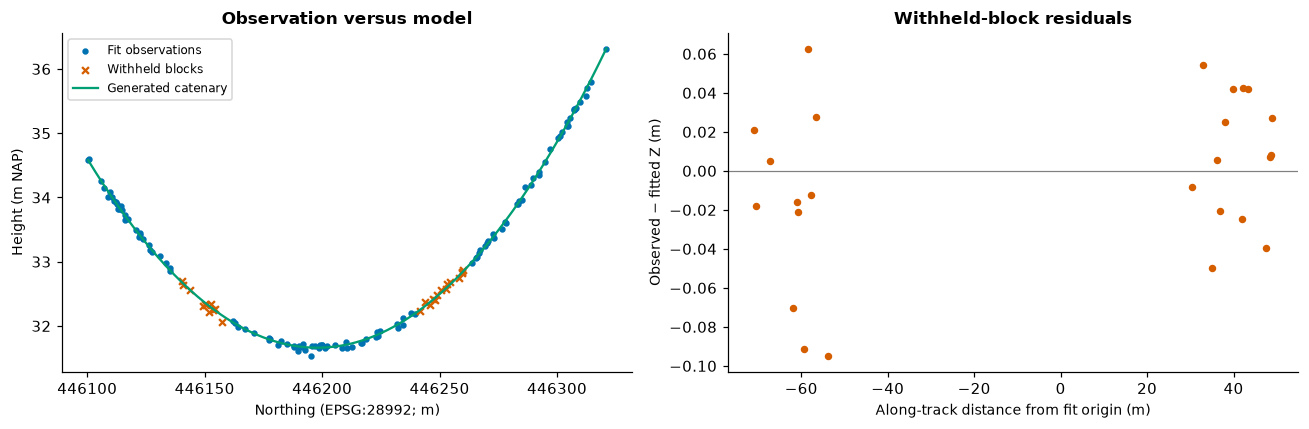

In [5]:
generated = fit["generated"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(
    observed[~held_out, 1], observed[~held_out, 2], s=10, color="#0072B2", label="Fit observations"
)
axes[0].scatter(
    observed[held_out, 1],
    observed[held_out, 2],
    s=20,
    marker="x",
    color="#D55E00",
    label="Withheld blocks",
)
axes[0].plot(generated[:, 1], generated[:, 2], color="#009E73", label="Generated catenary")
axes[0].set(
    xlabel="Northing (EPSG:28992; m)", ylabel="Height (m NAP)", title="Observation versus model"
)
axes[0].ticklabel_format(useOffset=False)
axes[0].legend(fontsize=8)
axes[1].scatter(s_test, test_residual, color="#D55E00", s=15)
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set(
    xlabel="Along-track distance from fit origin (m)",
    ylabel="Observed − fitted Z (m)",
    title="Withheld-block residuals",
)
plt.tight_layout()
plt.show()

In [6]:
from shapely.geometry import LineString, Point

from geoai_portfolio.io import sha256, write_json

evidence = gpd.GeoDataFrame(
    {
        "source_row": np.flatnonzero(wire_mask),
        "classification": 14,
        "evidence": "observed",
        "height_datum": "NAP EPSG:5709",
    },
    geometry=[Point(row) for row in wires],
    crs=28992,
)
modeled = gpd.GeoDataFrame(
    {
        "evidence": ["generated catenary"],
        "extrapolation": [False],
        "height_datum": ["NAP EPSG:5709"],
        "n_fit_points": [int((~held_out).sum())],
    },
    geometry=[LineString(generated)],
    crs=28992,
)
evidence.to_file(out / "conductor-evidence.gpkg", layer="observed_conductors", driver="GPKG")
modeled.to_file(out / "conductor-evidence.gpkg", layer="generated_curve", driver="GPKG")
np.testing.assert_array_equal(xyz, original_xyz)

write_json(
    out / "fit-provenance.json",
    {
        "source_sha256": sha256(data / "corridor.laz"),
        "selection": {
            "northing_m": [446100, 446330],
            "minimum_z_NAP_m": 30.5,
            "lateral_DBSCAN_eps_m": 0.4,
            "min_samples": 5,
        },
        "parameters": fit["parameters"].tolist(),
        "source_coordinates_unchanged": True,
        "fit_rmse_m": fit["rmse_m"],
        "withheld_rmse_m": float(np.sqrt(np.mean(test_residual**2))),
    },
)
display(
    pd.DataFrame(
        {
            "layer": ["observed_conductors", "generated_curve"],
            "features": [len(evidence), len(modeled)],
            "role": ["Original measured XYZ", "Fitted geometry within observed support"],
        }
    )
)

,layer,features,role
0,observed_conductors,1999,Original measured XYZ
1,generated_curve,1,Fitted geometry within observed support


## Transferable engineering decision

Preserve measured records and expose assumptions with generated geometry. A smooth
curve is useful for inspection, but it must not erase gaps or become a substitute for
observations without qualification. Separate layers, source-row identity, CRS, vertical
reference, fitting parameters and residuals allow another reader to audit that distinction.

[AHN source conventions](https://www.ahn.nl/dataroom) and
[laspy documentation](https://laspy.readthedocs.io/en/latest/) describe the data interfaces.